In [1]:
!pip install yfinance

In [2]:
import sys
!{sys.executable} -m pip install yfinance pandas numpy matplotlib seaborn scikit-learn ta xgboost

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Load Dataset

In [5]:
data = yf.download("RELIANCE.NS", start="2015-01-01", end="2024-01-01")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2015-01-01,189.999817,190.877171,189.090366,189.657446,2963643
2015-01-02,189.496933,191.743813,189.229456,190.042601,7331366
2015-01-05,187.421234,190.641759,187.046752,189.379224,10103941
2015-01-06,178.915253,186.811408,178.037899,186.169449,18627980
2015-01-07,182.809799,183.772746,179.107815,179.129214,20720312


In [6]:
#Understand Data

In [7]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2221 entries, 2015-01-01 to 2023-12-29
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   2221 non-null   float64
 1   (High, RELIANCE.NS)    2221 non-null   float64
 2   (Low, RELIANCE.NS)     2221 non-null   float64
 3   (Open, RELIANCE.NS)    2221 non-null   float64
 4   (Volume, RELIANCE.NS)  2221 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 104.1 KB


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
count,2221.000000,2221.000000,2221.000000,2221.000000,2.221000e+03
mean,654.967930,662.343850,648.140287,655.455241,1.900301e+07
std,370.662888,374.317949,367.263496,370.971811,1.399048e+07
min,173.490631,174.977847,170.430607,174.742467,1.705656e+06
25%,286.076782,290.777004,284.433423,287.314886,1.102748e+07
50%,569.417725,576.243553,564.201701,570.484949,1.498274e+07
75%,1054.023682,1068.658620,1039.196422,1051.960541,2.161084e+07
max,1297.294922,1303.754399,1283.922210,1299.582834,1.426834e+08


In [8]:
#Data Cleaning

In [9]:
data = data.dropna()

In [10]:
#Feature Engineering

In [11]:
# Moving averages
data['SMA_10'] = data['Close'].rolling(10).mean()
data['SMA_50'] = data['Close'].rolling(50).mean()

# Exponential Moving Average
data['EMA_10'] = data['Close'].ewm(span=10).mean()

# Returns
data['Returns'] = data['Close'].pct_change()

# Volatility
data['Volatility'] = data['Returns'].rolling(10).std()

In [12]:
#Add RSI

In [13]:
from ta.momentum import RSIIndicator

# FIX: convert to 1D
close_prices = data['Close'].squeeze()

rsi = RSIIndicator(close=close_prices, window=14)
data['RSI'] = rsi.rsi()

In [14]:
#Drop NaN after feature creation

In [15]:
data = data.dropna()

In [16]:
#Create Target Variable

In [17]:
data['Target'] = data['Close'].shift(-1)
data = data.dropna()

In [18]:
#Define Features & Labels

In [19]:
X = data.drop(['Target'], axis=1)
y = data['Target']

In [20]:
#Train-Test Split

In [21]:
split = int(len(data) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [22]:
#Feature Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
#Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [26]:
#Random Forest Regressor

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [28]:
#XGBoost Regressor

In [29]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [30]:
#Model Evaluation

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"{name} Performance:")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("----------------------")

evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, xgb_pred, "XGBoost")

Linear Regression Performance:
MAE: 11.688432575371019
RMSE: 15.82468904827984
----------------------
Random Forest Performance:
MAE: 19.577534098307297
RMSE: 26.60266592302096
----------------------
XGBoost Performance:
MAE: 24.552724412940016
RMSE: 32.762633408727105
----------------------


In [32]:
#Visualization

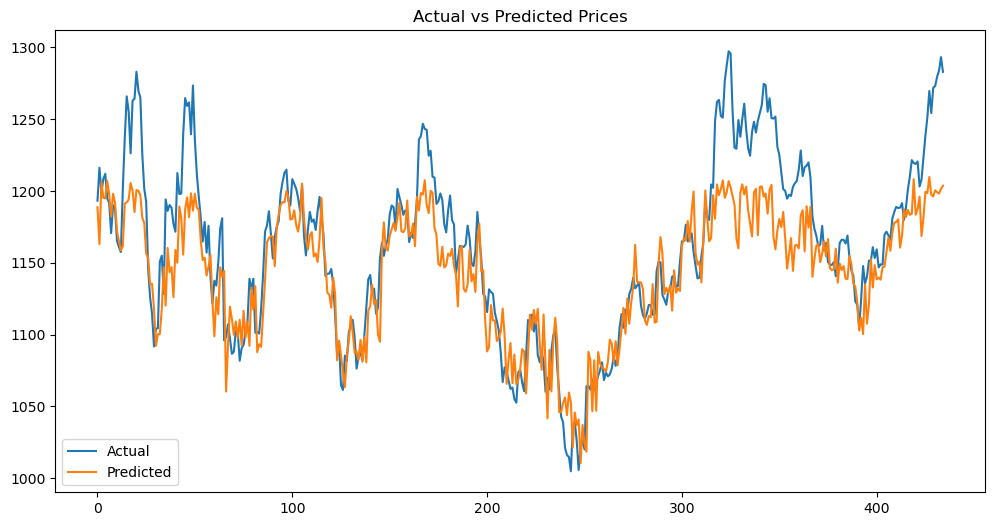

In [33]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(xgb_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.show()

In [34]:
#Model Comparison Table

In [35]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ]
})

results

,Model,RMSE
0,Linear Regression,15.824689
1,Random Forest,26.602666
2,XGBoost,32.762633


In [36]:
#Save Best Model

In [37]:
import pickle

pickle.dump(xgb, open("price_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))